### Imports necesarios para el Análisis

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Carga de datos

In [2]:
if input("¿Desea conectarse a la base de datos (sino cargará desde CSV)? (s/n): ").lower() == "s":

    load_dotenv()
    MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
    MYSQL_HOST = os.getenv("MYSQL_HOST")
    MYSQL_PORT = os.getenv("MYSQL_PORT")
    MYSQL_USER = os.getenv("MYSQL_USER")
    MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")

    try:
        # Crear motor de conexión
        engine = create_engine(
            f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
        )

        with engine.connect() :
            query = "SELECT * FROM RRHH_CLEAN;"
            df = pd.read_sql(query, engine)
        
        display("Datos de la base de datos cargados correctamente.")
        
    except SQLAlchemyError as error:
        display("No se pudo conectar o leer datos desde MySQL.")
        display(f"Detalle del error: {error}")
else:
    CSV_PATH = r'..\Data\DatasetClean_2026-06-29.csv'
    try:
        df = pd.read_csv(CSV_PATH)
        display("Datos cargados desde el archivo CSV correctamente.")

    except FileNotFoundError as error:
        raise FileNotFoundError(
            f"No se encontró el archivo CSV. Revisa la ruta: {CSV_PATH}"
    ) from error


'Datos cargados desde el archivo CSV correctamente.'

### Análisis Desempeño

Pregunta de negocio:
> ¿Cuál es el perfil sociodemográfico de los empleados de la empresa y cómo podemos utilizar esta información para diseñar políticas de talento más adaptadas a sus necesidades y potenciar su compromiso y desarrollo profesional?

La unidad de análisis es el **empleado**, identificado en el dataset mediante la variable `ID`.

Cada fila del dataset original representa una **solicitud de absentismo**.

Los pasos de análisis serán:

- Agregar los registros originales por `ID`, construyendo una tabla resumen por empleado.
- Definir perfiles o segmentos de empleados a partir de variables sociodemográficas.
- Visualizar las proporciones que cada perfil/segmento representa de los empleados.
- Proponer posibles líneas de actuación en materia de conciliación, desarrollo profesional, bienestar, prevención del absentismo y compromiso.

### Clasificación de variables

In [3]:
# A nivel de dominio de variables:
variables_sociodemograficas = [
    "Age", "Education_Desc", "Son", "Pet", "Social_Drinker", "Social_Smoker", "Body_Mass_Index", 
]

variables_laborales = [
    "Service_Time", "Transportation_Expense", "Distance_Residence_Work", "Work_load_Average_Day"
]

variables_desempeño = [
    "Hit_Target", "Disciplinary_Failure"
]

variables_absencia = [
    "Reason_Absence_Desc",  "Absenteeism_Hours", "Month_Absence", "Day_Week_Desc", "Season_Desc"
]


df_analisis = df[variables_sociodemograficas + variables_laborales + variables_desempeño + variables_absencia].copy()
df_analisis['ID_Employee'] = df['ID_Employee']

### Definir variables como categóricas y booleanas

In [4]:
variables_categoricas = [
    'Reason_Absence_Desc', 'Month_Absence', 'Day_Week_Desc', 'Season_Desc', 'Education_Desc'
]

variables_booleanas = ['Disciplinary_Failure', 'Social_Drinker', 'Social_Smoker']

variables_discretas = ['Son', 'Pet' ]

variables_continuas = [
    'Transportation_Expense', 'Distance_Residence_Work', 'Work_load_Average_Day', 'Age', 
    'Hit_Target', 'Body_Mass_Index', 'Absenteeism_Hours', 'Service_Time'
]

In [5]:
for col in variables_categoricas:
    df_analisis[col] = df_analisis[col].astype("category")

df_analisis["Education_Desc"] = pd.Categorical(
    df_analisis["Education_Desc"],
    categories=[
        "Educación secundaria",
        "Graduado",
        "Postgrado",
        "Máster o doctorado"
    ],
    ordered=True
)

for col in variables_booleanas:
    df_analisis[col] = df_analisis[col].astype("boolean")

df_analisis.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      705 non-null    int64   
 1   Education_Desc           705 non-null    category
 2   Son                      705 non-null    int64   
 3   Pet                      705 non-null    int64   
 4   Social_Drinker           705 non-null    boolean 
 5   Social_Smoker            705 non-null    boolean 
 6   Body_Mass_Index          705 non-null    int64   
 7   Service_Time             705 non-null    int64   
 8   Transportation_Expense   705 non-null    int64   
 9   Distance_Residence_Work  705 non-null    int64   
 10  Work_load_Average_Day    705 non-null    float64 
 11  Hit_Target               705 non-null    int64   
 12  Disciplinary_Failure     705 non-null    boolean 
 13  Reason_Absence_Desc      705 non-null    category
 14  Absenteeism_Hours    

### Generar el dataset por empleado `ID`

#### Comprobar variabilidad del empleado

In [6]:
variables_a_revisar = variables_sociodemograficas + variables_laborales + variables_desempeño + variables_absencia

variabilidad_empleado = (
    df_analisis
    .groupby("ID_Employee")[variables_a_revisar]
    .nunique()
    .reset_index()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

variabilidad_empleado

,ID_Employee,Age,Education_Desc,Son,Pet,Social_Drinker,Social_Smoker,Body_Mass_Index,Service_Time,Transportation_Expense,Distance_Residence_Work,Work_load_Average_Day,Hit_Target,Disciplinary_Failure,Reason_Absence_Desc,Absenteeism_Hours,Month_Absence,Day_Week_Desc,Season_Desc
0,1,1,1,1,1,1,1,1,1,1,1,17,11,2,13,7,10,5,4
1,2,1,1,1,1,1,1,1,1,1,1,4,2,2,4,3,4,3,2
2,3,1,1,1,1,1,1,1,1,1,1,30,13,2,14,9,12,5,4
3,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,5,1,1,1,1,1,1,1,1,1,1,14,9,2,5,5,9,5,4
5,6,1,1,1,1,1,1,1,1,1,1,7,5,1,5,2,5,3,4
6,7,1,1,1,1,1,1,1,1,1,1,5,3,2,4,5,4,4,4
7,8,1,1,1,1,1,1,1,1,1,1,2,2,2,1,1,2,2,2
8,9,1,1,1,1,1,1,1,1,1,1,5,4,1,5,6,5,3,4
9,10,1,1,1,1,1,1,1,1,1,1,19,9,1,10,6,10,5,4


#### Generación dataset de empleado

In [7]:
def moda_unica(s):
    """
    Devuelve el valor más frecuente de una serie.
    - Si hay empate, pandas devuelve varias modas; tomamos la primera para obtener
      un único valor por empleado.
    """
    moda = s.mode(dropna=True)
    return moda.iloc[0]

df_empleado = (
    df_analisis
    .groupby("ID_Employee")
    .agg(
        eventos_absentismo=("Absenteeism_Hours", "count"),
        absentismo_total_horas=("Absenteeism_Hours", "sum"),
        absentismo_media_horas=("Absenteeism_Hours", "mean"),
        absentismo_mediana_horas=("Absenteeism_Hours", "median"),
        absentismo_max_horas=("Absenteeism_Hours", "max"),
        mes_ausencia_mas_frecuente=("Month_Absence", moda_unica),
        dia_ausencia_mas_frecuente=("Day_Week_Desc", moda_unica),
        estacion_ausencia_mas_frecuente=("Season_Desc", moda_unica),

        rendimiento_medio=("Hit_Target", "mean"),
        rendimiento_mediana=("Hit_Target", "median"),
        carga_media=("Work_load_Average_Day", "mean"),
        carga_mediana=("Work_load_Average_Day", "median"),

        tuvo_fallo_disciplinario=("Disciplinary_Failure", "max"),

        edad=("Age", "max"),
        educacion=("Education_Desc", "max"),
        hijos=("Son", "max"),
        mascotas=("Pet", "max"),
        bebedor_social=("Social_Drinker", moda_unica),
        fumador_social=("Social_Smoker", moda_unica),

        imc=("Body_Mass_Index", "median"),
        antiguedad=("Service_Time", "max"),
        distancia_trabajo=("Distance_Residence_Work", "median"),
        gasto_transporte=("Transportation_Expense", "median"),
        motivo_ausencia_mas_frecuente=("Reason_Absence_Desc", moda_unica)
    )
    .reset_index()
)

df_empleado

,ID_Employee,eventos_absentismo,absentismo_total_horas,absentismo_media_horas,absentismo_mediana_horas,absentismo_max_horas,mes_ausencia_mas_frecuente,dia_ausencia_mas_frecuente,estacion_ausencia_mas_frecuente,rendimiento_medio,rendimiento_mediana,carga_media,carga_mediana,tuvo_fallo_disciplinario,edad,educacion,hijos,mascotas,bebedor_social,fumador_social,imc,antiguedad,distancia_trabajo,gasto_transporte,motivo_ausencia_mas_frecuente
0,1,23,121,5.260870,4.0,16,8,Jueves,Verano,95.173913,95.0,262.894478,249.7970,True,37,Postgrado,1,1,False,False,29.0,14,11.0,235.0,Consulta médica
1,2,6,25,4.166667,4.5,8,8,Lunes,Verano,93.333333,92.0,241.597000,218.1035,True,48,Educación secundaria,1,5,False,True,33.0,12,29.0,235.0,Sin ausencia registrada
2,3,97,444,4.577320,3.0,32,2,Lunes,Otoño,94.762887,96.0,264.747216,253.9570,True,38,Educación secundaria,0,0,True,False,31.0,18,51.0,179.0,Consulta dental
3,4,1,0,0.000000,0.0,0,0,Martes,Verano,95.000000,95.0,271.219000,271.2190,False,40,Educación secundaria,1,8,True,False,34.0,13,14.0,118.0,Sin ausencia registrada
4,5,18,102,5.666667,8.0,16,9,Lunes,Primavera,91.722222,93.0,266.741389,265.0170,True,43,Educación secundaria,1,0,True,False,38.0,13,20.0,235.0,Ausencia injustificada
5,6,8,72,9.000000,8.0,16,2,Jueves,Otoño,94.875000,94.5,274.829000,274.7285,False,33,Educación secundaria,2,2,False,False,25.0,13,29.0,189.0,Seguimiento de paciente
6,7,6,30,5.000000,3.0,16,3,Jueves,Invierno,94.666667,95.0,303.210833,313.6420,True,39,Educación secundaria,2,0,True,True,24.0,14,5.0,279.0,Enfermedades del sistema genito-urinario
7,8,2,0,0.000000,0.0,0,0,Martes,Otoño,88.000000,88.0,282.718000,282.7180,True,39,Educación secundaria,2,2,True,False,35.0,14,35.0,231.0,Sin ausencia registrada
8,9,8,262,32.750000,8.0,120,3,Martes,Otoño,95.875000,96.5,249.042250,255.3390,False,58,Educación secundaria,2,1,False,False,22.0,16,14.0,228.0,Enfermedades del sistema nervioso
9,10,23,178,7.739130,8.0,40,7,Lunes,Verano,94.000000,93.0,258.764348,253.4650,False,28,Educación secundaria,1,4,True,False,27.0,3,52.0,361.0,Seguimiento de paciente


In [8]:
variables_discretas_empleado = ["hijos", "mascotas"]
variables_booleanas_empleado = ["bebedor_social", "fumador_social", "tuvo_fallo_disciplinario"]
variables_continuas_empleado = [
    "eventos_absentismo", "absentismo_total_horas", "absentismo_media_horas", "absentismo_mediana_horas",
    "absentismo_max_horas", "rendimiento_medio", "rendimiento_mediana", "carga_media","carga_mediana",
     "edad", "imc", "antiguedad", "distancia_trabajo", "gasto_transporte"
]
variables_categoricas_empleado = [
    "educacion", "mes_ausencia_mas_frecuente", "dia_ausencia_mas_frecuente", "estacion_ausencia_mas_frecuente", 
    "motivo_ausencia_mas_frecuente"
] 

### Dataset de Empleado

In [9]:
print(f"Eventos originales: {len(df)}")
print(f"Empleados en tabla agregada: {len(df_empleado)}")
print(f"IDs únicos originales: {df['ID_Employee'].nunique()}")

Eventos originales: 705
Empleados en tabla agregada: 36
IDs únicos originales: 36


#### Estadisticas del dataset Empleado

In [10]:
df_empleado[variables_continuas_empleado+variables_discretas_empleado].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
eventos_absentismo,36.0,19.58,21.47,1.0,5.00,9.00,28.25,97.00
absentismo_total_horas,36.0,140.08,145.25,0.0,24.00,78.00,251.00,476.00
absentismo_media_horas,36.0,6.91,5.79,0.0,4.37,5.33,7.80,32.75
absentismo_mediana_horas,36.0,4.61,2.82,0.0,2.75,3.50,8.00,8.00
absentismo_max_horas,36.0,35.67,38.55,0.0,8.00,16.00,58.00,120.00
rendimiento_medio,36.0,94.52,1.99,88.0,93.96,94.83,95.62,98.50
rendimiento_mediana,36.0,94.75,2.24,88.0,93.88,95.00,96.00,99.00
carga_media,36.0,272.74,19.25,241.6,262.57,270.04,281.58,328.02
carga_mediana,36.0,268.12,20.00,218.1,255.32,265.02,276.89,313.64
edad,36.0,38.33,7.92,27.0,32.00,37.50,43.00,58.00


In [11]:
df_empleado[variables_categoricas_empleado+variables_booleanas_empleado].describe().T


,count,unique,top,freq
educacion,36,4,Educación secundaria,28
mes_ausencia_mas_frecuente,36,10,3,6
dia_ausencia_mas_frecuente,36,5,Lunes,12
estacion_ausencia_mas_frecuente,36,4,Verano,10
motivo_ausencia_mas_frecuente,36,12,Consulta dental,10
bebedor_social,36,2,True,19
fumador_social,36,2,False,29
tuvo_fallo_disciplinario,36,2,True,20


### Perfiles sociodemográficos

In [22]:
df_empleado["grupo_edad"] = pd.cut(
    df_empleado["edad"],
    bins=[0, 29, 40, 50, np.inf],
    labels=["menor de 30", "entre 30 y 40", "entre 40 y 50", "mayor de 50"],
    ordered=True
)

df_empleado["grupo_educacion"] = df_empleado["educacion"]

df_empleado["grupo_hijos"] = pd.cut(
    df_empleado["hijos"],
    bins=[-1, 0, 1, np.inf],
    labels=["Sin hijos", "1 hijo", "2 o más hijos"],
    ordered=True
)

df_empleado["grupo_mascotas"] = pd.cut(
    df_empleado["mascotas"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["Sin mascotas", "1 mascota", "2 mascotas", "3 o más mascotas"],
    ordered=True
)

df_empleado["grupo_bebedor_social"] = df_empleado["bebedor_social"].map({
    False: "No bebedor",
    True: "Bebedor social"
})

df_empleado["grupo_fumador_social"] = df_empleado["fumador_social"].map({
    False: "No fumador",
    True: "Fumador social"
})

df_empleado["grupo_imc"] = pd.cut(
    df_empleado["imc"],
    bins=[0, 24.9, 29.9, np.inf],
    labels=["normal", "sobrepeso", "obesidad"],
    ordered=True
)

df_empleado["grupo_distancia"] = pd.cut(
    df_empleado["distancia_trabajo"],
    bins=[0, 15, 35, np.inf],
    labels=["menos de 15 km", "entre 15 y 35 km", "más de 35 km"],
    ordered=True
)

df_empleado["grupo_gasto_transporte"] = pd.cut(
    df_empleado["gasto_transporte"],
    bins=[0, 180, 280, np.inf],
    labels=["menos de 180 BRL", "entre 180 y 280 BRL", "más de 280 BRL"],
    ordered=True
)

df_empleado["grupo_antiguedad"] = pd.cut(
    df_empleado["antiguedad"],
    bins=[0, 5, 15, np.inf],
    labels=["menos de 5 años", "5 a 15 años", "más de 15 años"],
    ordered=True
)

df_empleado[[
    "ID_Employee", "grupo_edad", "grupo_educacion", "grupo_hijos",
    "grupo_mascotas", "grupo_bebedor_social", "grupo_fumador_social", 
    "grupo_imc", "grupo_distancia", "grupo_gasto_transporte", "grupo_antiguedad"
]]

,ID_Employee,grupo_edad,grupo_educacion,grupo_hijos,grupo_mascotas,grupo_bebedor_social,grupo_fumador_social,grupo_imc,grupo_distancia,grupo_gasto_transporte,grupo_antiguedad
0,1,entre 30 y 40,Postgrado,1 hijo,1 mascota,No bebedor,No fumador,sobrepeso,menos de 15 km,entre 180 y 280 BRL,5 a 15 años
1,2,entre 40 y 50,Educación secundaria,1 hijo,3 o más mascotas,No bebedor,Fumador social,obesidad,entre 15 y 35 km,entre 180 y 280 BRL,5 a 15 años
2,3,entre 30 y 40,Educación secundaria,Sin hijos,Sin mascotas,Bebedor social,No fumador,obesidad,más de 35 km,menos de 180 BRL,más de 15 años
3,4,entre 30 y 40,Educación secundaria,1 hijo,3 o más mascotas,Bebedor social,No fumador,obesidad,menos de 15 km,menos de 180 BRL,5 a 15 años
4,5,entre 40 y 50,Educación secundaria,1 hijo,Sin mascotas,Bebedor social,No fumador,obesidad,entre 15 y 35 km,entre 180 y 280 BRL,5 a 15 años
5,6,entre 30 y 40,Educación secundaria,2 o más hijos,2 mascotas,No bebedor,No fumador,sobrepeso,entre 15 y 35 km,entre 180 y 280 BRL,5 a 15 años
6,7,entre 30 y 40,Educación secundaria,2 o más hijos,Sin mascotas,Bebedor social,Fumador social,normal,menos de 15 km,entre 180 y 280 BRL,5 a 15 años
7,8,entre 30 y 40,Educación secundaria,2 o más hijos,2 mascotas,Bebedor social,No fumador,obesidad,entre 15 y 35 km,entre 180 y 280 BRL,5 a 15 años
8,9,mayor de 50,Educación secundaria,2 o más hijos,1 mascota,No bebedor,No fumador,normal,menos de 15 km,entre 180 y 280 BRL,más de 15 años
9,10,menor de 30,Educación secundaria,1 hijo,3 o más mascotas,Bebedor social,No fumador,sobrepeso,más de 35 km,más de 280 BRL,menos de 5 años


#### Empleado Perfil Medio

In [13]:
perfil_medio_numerico = (
    df_empleado[variables_continuas_empleado + variables_discretas_empleado]
    .agg(["mean", "median", "min", "max"])
    .T
    .round(2)
)

perfil_medio_categorico = (
    df_empleado[variables_categoricas_empleado + variables_booleanas_empleado]
    .mode(dropna=True)
    .iloc[0]
    .to_frame(name="valor_mas_frecuente")
)

display(perfil_medio_numerico)
display(perfil_medio_categorico)

perfil_medio = pd.concat(
    [
        perfil_medio_numerico['median'],
        perfil_medio_categorico["valor_mas_frecuente"]
    ],
    axis=0
)

,mean,median,min,max
eventos_absentismo,19.58,9.00,1.0,97.00
absentismo_total_horas,140.08,78.00,0.0,476.00
absentismo_media_horas,6.91,5.33,0.0,32.75
absentismo_mediana_horas,4.61,3.50,0.0,8.00
absentismo_max_horas,35.67,16.00,0.0,120.00
rendimiento_medio,94.52,94.83,88.0,98.50
rendimiento_mediana,94.75,95.00,88.0,99.00
carga_media,272.74,270.04,241.6,328.02
carga_mediana,268.12,265.02,218.1,313.64
edad,38.33,37.50,27.0,58.00


,valor_mas_frecuente
educacion,Educación secundaria
mes_ausencia_mas_frecuente,3
dia_ausencia_mas_frecuente,Lunes
estacion_ausencia_mas_frecuente,Verano
motivo_ausencia_mas_frecuente,Consulta dental
bebedor_social,True
fumador_social,False
tuvo_fallo_disciplinario,True


#### Porcentaje representativo de la plantilla de empleados por segmento

In [14]:
segmentos = [
    "grupo_edad", "grupo_educacion", "grupo_hijos", "grupo_mascotas",
    "grupo_bebedor_social", "grupo_fumador_social", "grupo_imc",
    "grupo_distancia", "grupo_gasto_transporte", "grupo_antiguedad"
]

for col in segmentos:
    tabla = (
        df_empleado[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="empleados")
    )
    tabla["porcentaje"] = (tabla["empleados"] / len(df_empleado) * 100).round(2)
    print(f"\nSegmento: {col}")
    display(tabla)


Segmento: grupo_edad


,grupo_edad,empleados,porcentaje
0,entre 30 y 40,19,52.78
1,entre 40 y 50,10,27.78
2,menor de 30,5,13.89
3,mayor de 50,2,5.56



Segmento: grupo_educacion


,grupo_educacion,empleados,porcentaje
0,Educación secundaria,28,77.78
1,Graduado,4,11.11
2,Postgrado,3,8.33
3,Máster o doctorado,1,2.78



Segmento: grupo_hijos


...

,grupo_distancia,empleados,porcentaje
0,entre 15 y 35 km,15,41.67
1,menos de 15 km,11,30.56
2,más de 35 km,10,27.78



Segmento: grupo_gasto_transporte


,grupo_gasto_transporte,empleados,porcentaje
0,entre 180 y 280 BRL,16,44.44
1,menos de 180 BRL,10,27.78
2,más de 280 BRL,10,27.78



Segmento: grupo_antiguedad


,grupo_antiguedad,empleados,porcentaje
0,5 a 15 años,26,72.22
1,más de 15 años,7,19.44
2,menos de 5 años,3,8.33


### Visualizaciones del perfil sociodemográfico

In [15]:
grupos_sociodemograficos = {
    "grupo_edad" : "por grupo de edad",
    "grupo_educacion" : "por nivel educativo",
    "grupo_hijos" : "según número de hijos",
    "grupo_mascotas" : "según número de mascotas",
    "grupo_bebedor_social" : "según consumo social de alcohol",
    "grupo_fumador_social" : "según hábito de fumar",
    "grupo_imc" : "por grupo de IMC"
}

grupos_contexto_talento = {
    "grupo_distancia" : "según distancia al trabajo",
    "grupo_gasto_transporte" : "según gasto de transporte",
    "grupo_antiguedad" : "por antigüedad"
}

grupos_visualizacion = {**grupos_sociodemograficos, **grupos_contexto_talento}

palette_base = ["steelblue", "darkorange", "#2a9d8f", "#e76f51", "#264653", "grey"]

visualizacion_disco = ["grupo_bebedor_social","grupo_fumador_social"]


def tabla_representacion_grupo(df_base, grupo):
    tabla = (
        df_base[grupo]
        .value_counts(dropna=False)
        .rename_axis(grupo)
        .reset_index(name="empleados")
    )
    tabla["porcentaje"] = (tabla["empleados"] / len(df_base) * 100).round(1)
    return tabla

#### Representación de los grupos sociodemográficos

In [16]:
def autopct_con_n(values):
    def formato(pct):
        total = sum(values)
        n = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(n={n})"
    return formato

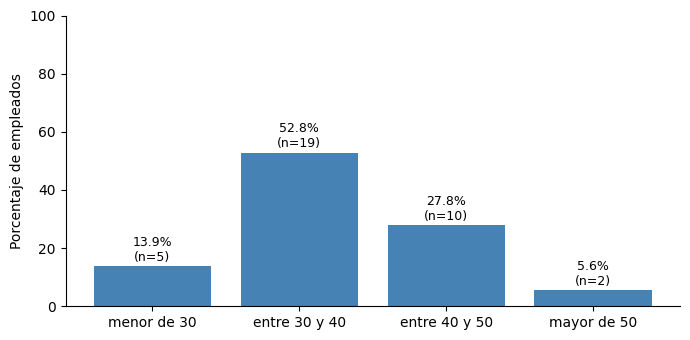

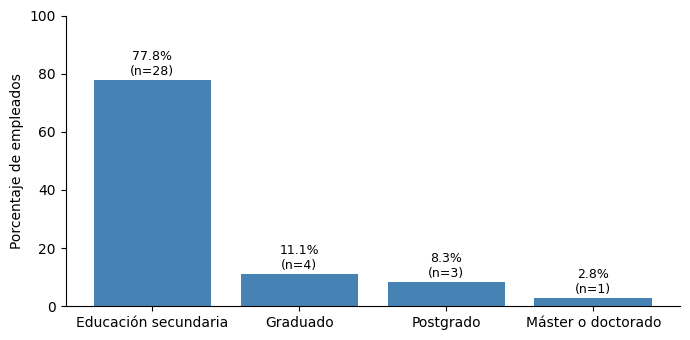

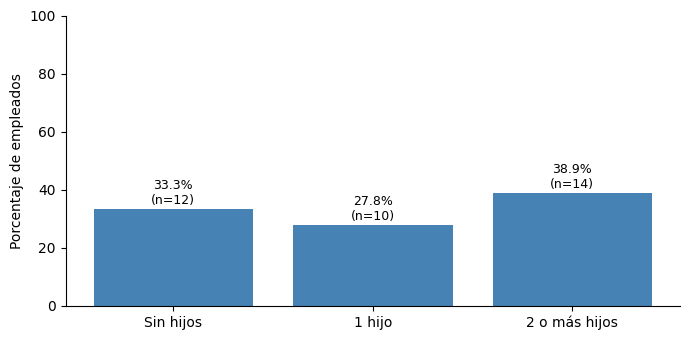

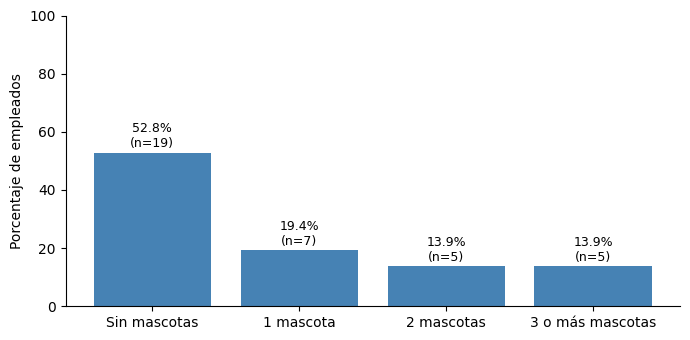

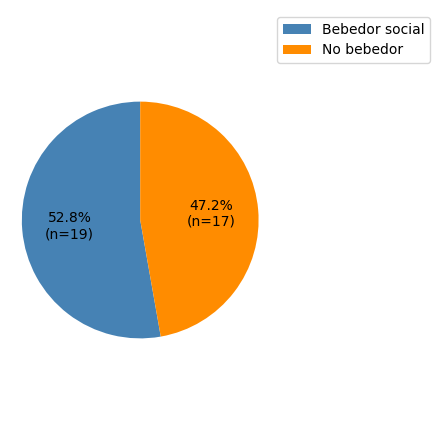

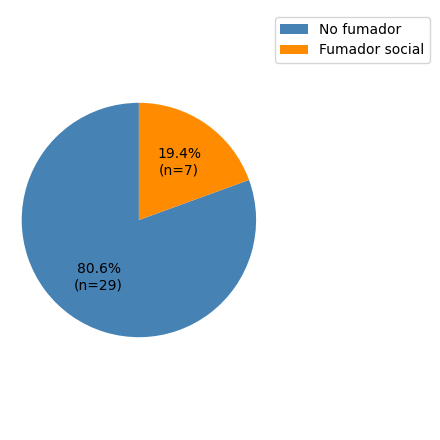

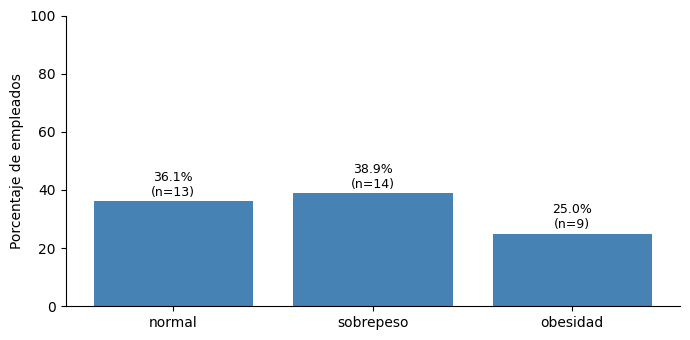

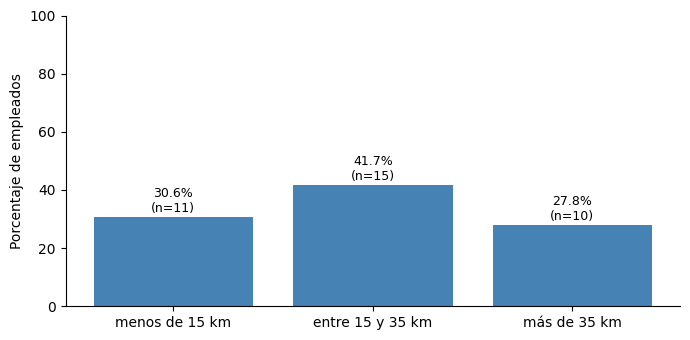

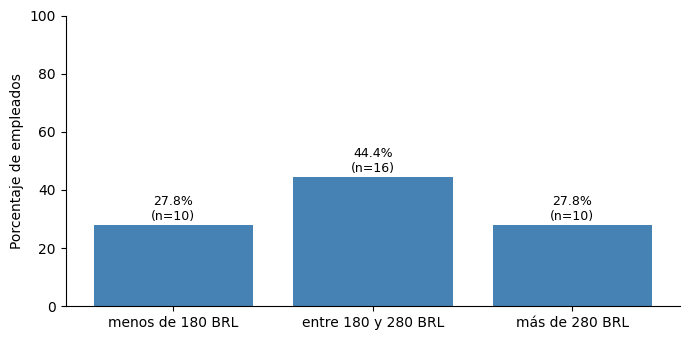

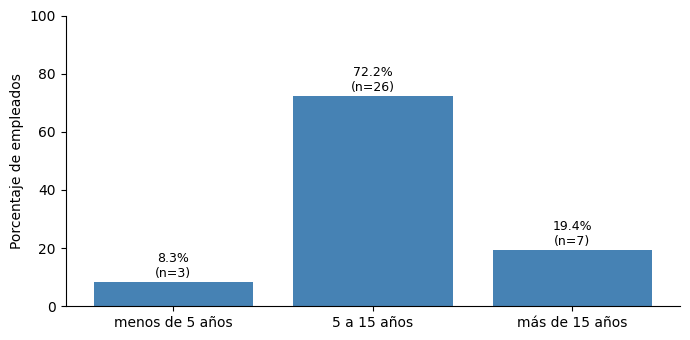

In [23]:
for grupo, nombre in grupos_visualizacion.items():
    tabla = tabla_representacion_grupo(df_empleado, grupo)
    
    if grupo in visualizacion_disco:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))


        wedges, texts, autotexts = ax.pie(
            tabla["empleados"],
            labels=None,
            autopct=autopct_con_n(tabla["empleados"]),
            startangle=90,
            colors=palette_base[:len(tabla)],
            textprops={"fontsize": 10},
            radius=1
        )

        ax.legend(
            wedges,
            tabla[grupo].astype(str),
            title=None,
            loc="upper left",
            bbox_to_anchor=(1, 1)
        )

        ax.axis("equal")
        plt.subplots_adjust(left=0.05, right=0.72, top=0.88, bottom=0.08)

    else:
        plt.figure(figsize=(7, 3.5))
        tabla = tabla.sort_values(grupo)
        bars = plt.bar(tabla[grupo].astype(str), tabla["porcentaje"], color="steelblue")
    
        for bar, pct, n in zip(bars, tabla["porcentaje"], tabla["empleados"]):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{pct:.1f}%\n(n={n})",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.xlabel("")
        plt.ylabel("Porcentaje de empleados")
        plt.xticks(rotation=0, ha="center")
        plt.ylim(0, 100)
        ax = plt.gca()
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    #plt.title(f"Distribución de empleados {nombre}", fontsize=13, fontweight="bold", pad=25)
    plt.tight_layout()
    plt.show()

#### Cruces relevantes para perfiles

Estos cruces ayudan a detectar si los empleados se concentran en determinados perfiles compuestos.

Se añaden tres gráficos:

1. Edad × educación: aproxima etapa vital y nivel formativo.
2. Edad × distancia: útil para políticas de movilidad/flexibilidad.
3. Edad × hijos: útil para políticas de conciliación.


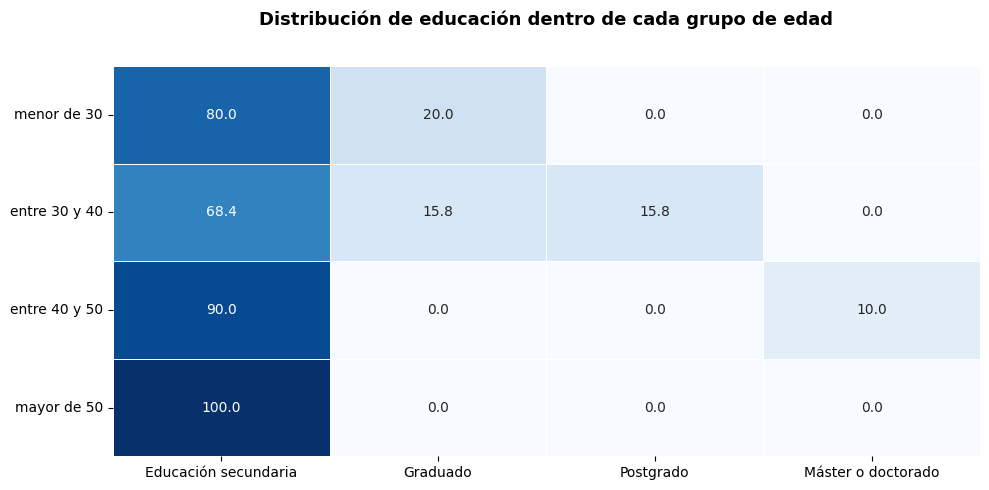

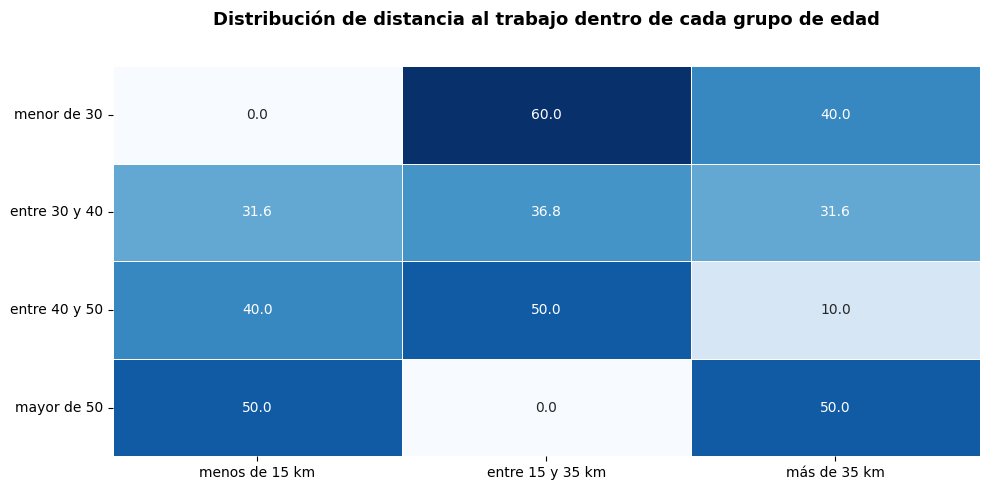

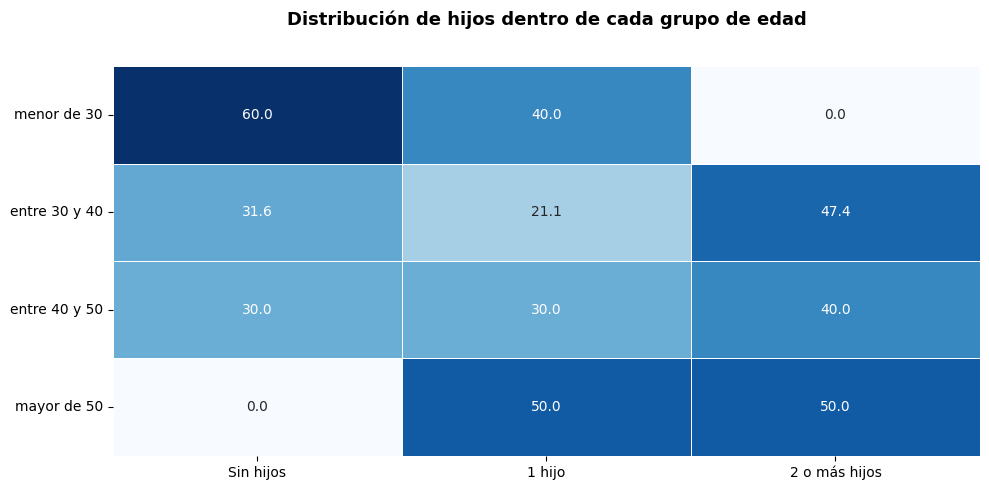

In [18]:
def heatmap_porcentaje_cruce(df_base, fila, columna, titulo):
    tabla = pd.crosstab(
        df_base[fila],
        df_base[columna],
        normalize="index"
    ) * 100
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(
        tabla,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        linewidths=0.5,
        cbar=False
    )
    plt.title(titulo, fontsize=13, fontweight="bold", pad=30)

    plt.xlabel("")
    plt.ylabel("")

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

heatmap_porcentaje_cruce(
    df_empleado,
    "grupo_edad",
    "grupo_educacion",
    "Distribución de educación dentro de cada grupo de edad"
)

heatmap_porcentaje_cruce(
    df_empleado,
    "grupo_edad",
    "grupo_distancia",
    "Distribución de distancia al trabajo dentro de cada grupo de edad"
)

heatmap_porcentaje_cruce(
    df_empleado,
    "grupo_edad",
    "grupo_hijos",
     "Distribución de hijos dentro de cada grupo de edad"
)

### Conclusiones, propuestas de como utilizar la información de los perfiles

La información disponible permite construir una visión integrada de los empleados combinando variables sociodemográficas, laborales y de desempeño.

El perfil típico identificado es un empleado de unos 38 años, con educación secundaria, un hijo, aproximadamente 13 años de antigüedad, una distancia mediana al trabajo de 25,5 km, un gasto de transporte mediano de 235, un rendimiento medio alto cercano al 95% y una mediana de 78 horas totales de absentismo, siendo la consulta dental el motivo más habitual.

A continuación se proponen líneas de actuación en cuatro áreas.

#### 1. Políticas de desarrollo enfocadas al nivel educativo

El 77,8% de la plantilla tiene educación secundaria. El desarrollo profesional debería priorizar la formación práctica, modular y certificable frente a los itinerarios académicos tradicionales.

**Recomendación de negocio:**
- Crear itinerarios cortos de capacitación en liderazgo operativo, planificación de rutas, gestión de incidencias, atención al cliente y herramientas digitales.
- Diseñar rutas de carrera desde posiciones operativas hacia coordinador de equipo, formador interno, supervisor de rutas o planificación logística.
- Usar a los empleados con mayor antigüedad como mentores, especialmente porque hay una base importante de experiencia acumulada.

#### 2. Conciliación y flexibilidad según etapa vital

La plantilla se concentra entre 30 y 40 años (52,8%) y entre 40 y 50 años (27,8%). Además, el 66,7% tiene al menos un hijo y el 38,9% tiene dos o más. Esto apunta a una plantilla en una etapa vital donde la conciliación puede ser crítica para el compromiso.

**Recomendación de negocio:**
- Ofrecer mayor previsibilidad de turnos y rutas.
- Facilitar cambios de turno planificados.
- Diseñar medidas específicas para empleados con responsabilidades familiares, especialmente en campañas de alta demanda.
- Analizar si el absentismo concentrado en lunes o en verano puede estar relacionado con tensiones de conciliación, vacaciones escolares o cargas familiares.

#### 3. Bienestar físico y prevención del absentismo

El análisis muestra que el 38,9% de la plantilla tiene sobrepeso y el 25% presenta obesidad. En una empresa de reparto, donde hay exigencia física por conducción, carga y trabajo en almacén, este dato es especialmente relevante.

**Recomendación de negocio:**
- Programas voluntarios de salud física, ergonomía, prevención de lesiones y hábitos saludables.
- Revisión de cargas, rutas, tiempos de descanso y exposición física.
- Campañas preventivas de salud dental, ya que la "consulta dental" aparece como el motivo de ausencia más frecuente.

#### 4. Movilidad, transporte y compromiso

Un 27,8% de los empleados vive lejos. Y un 70% de los empleados tiene un gasto medio, alto en transporte. 


**Recomendación de negocio:**
- Valorar ayudas de transporte para empleados con mayor distancia o coste.
- Optimizar asignación de centros, rutas o bases cuando sea posible.
- Explorar turnos compactos o más previsibles para quienes viven más lejos.